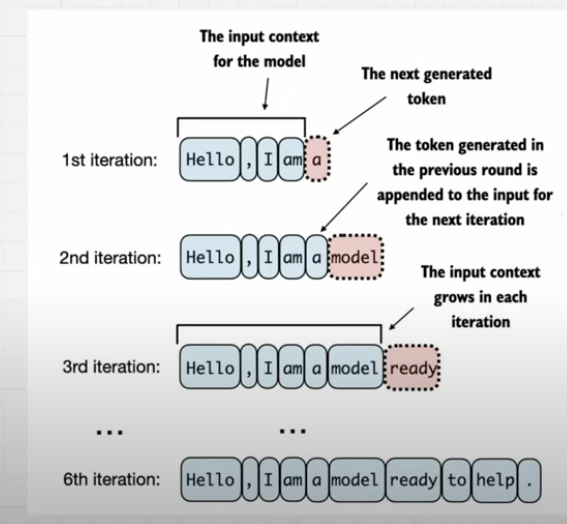

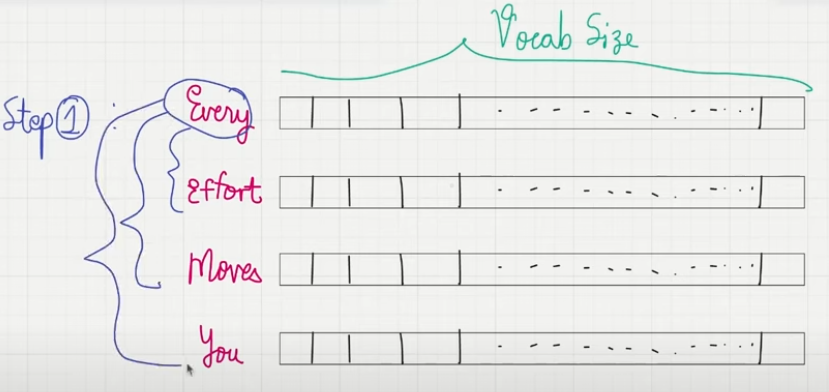
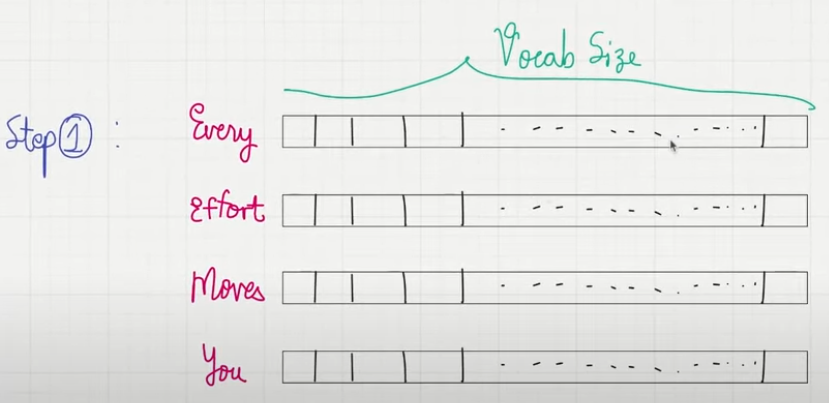

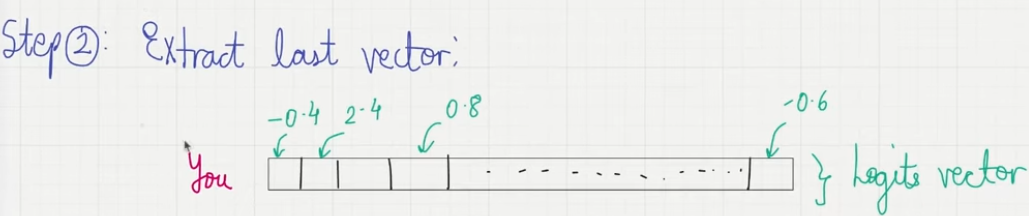

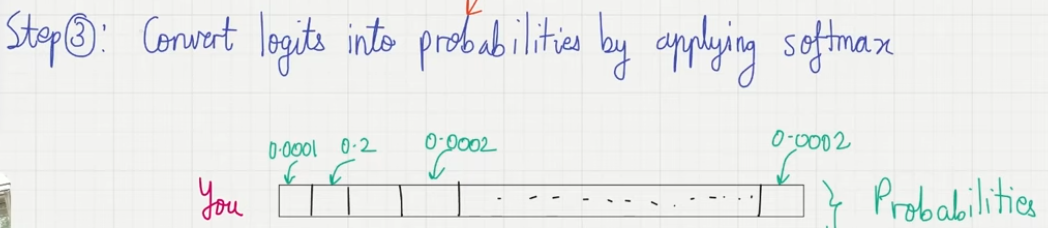

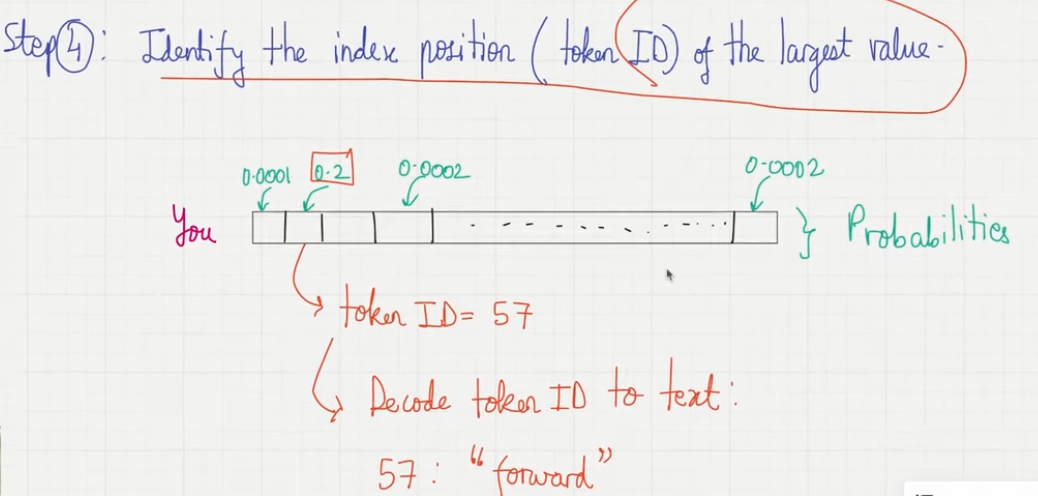

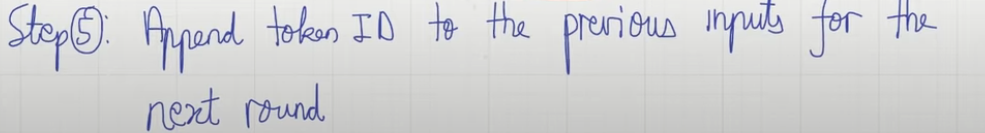

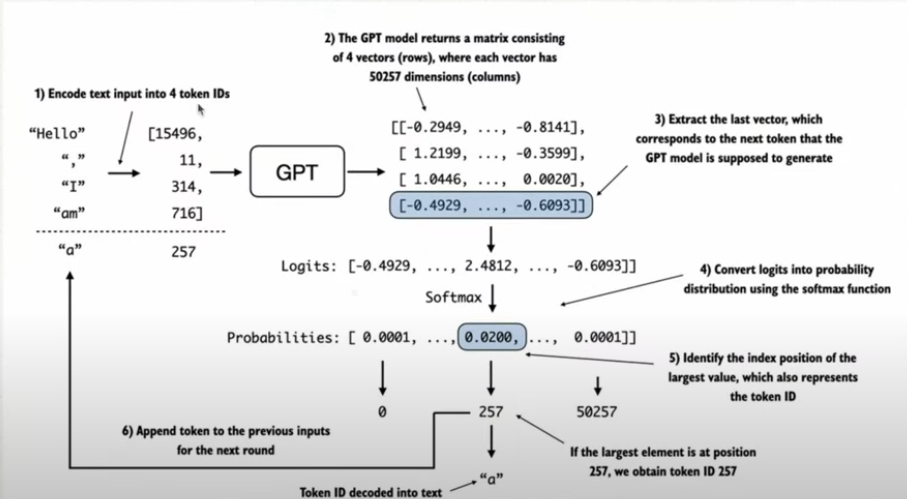

In each step, the model outputs a mtrix with vectors representing the potential next token. 

The vecotr corresponding to the next token is extrcated and converted into a probability distribution via the softmax function. 

From this probability distribution, extract the index with the highest probability, get it token id and decode it back to text.

So that's we have produces a new token and predicted it. 

Now just append it to the previous inputs so that we can geneate the new token. As shown in the baove diagram

This step by step process enables the model to generate text sequentially, building coherent phrases from the initial input context. 

In practice, we repeat this process over many iterations, until we reach a user specified number of generated tokens. 


**Max tokens and context lenght are different.**

The figure below ilustrates the process of generating one token id at a time. 

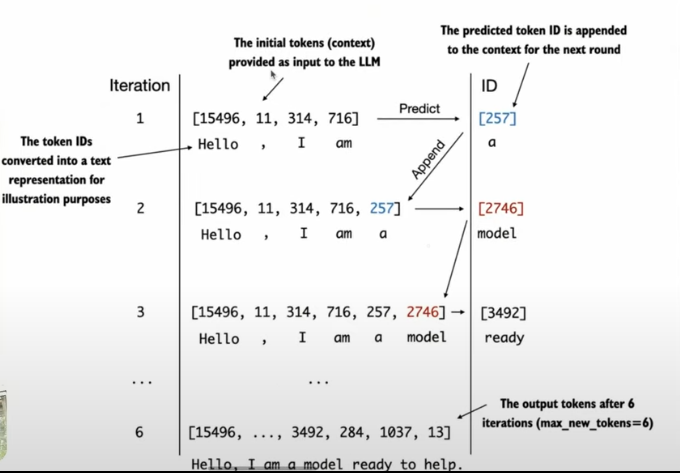
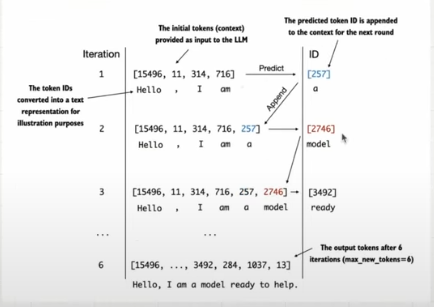

In Iteration 1,
1. The model is provided with token corresponding to "Hello, I am"
2. Predicts new token with token ID 257 -> "a"
3. Appends this new predited token back to the input. 

In iteration 2, 
Now the model will have "Hello, I am a" as an input. 


This process is repeated till the model produces the complete sentenc: "Hello, I am a model ready to help" After 6 iterations. 

Why only 6? -> Because the mac_new_tokens was set to 6.


### The process for implementing the next predicition is as follows: 

**Step 1: idx is a (batch, n_tokens) array of indices in the current context**

Example: 
Input batch:

 tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])

**Step 2: Crop current context if it exceeds the supported context size E.g., if LLM supports only 5 tokens, and the context size is 10 then only the last 5 tokens are used as context**

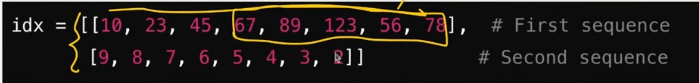

**Step 3: Focus only on the last time step, so that (batch, n_token, vocab_size) becomes (batch, vocab_size)** 

Extract the last token logit only, which will be used for predicition 

**Step 4: probas has shape (batch, vocab_size)**  

Last row, is converted to prob using softmax

**Step 5: idx_next has shape (batch, 1)**

**Step 6: Append sampled index to the running sequence, where idx has shape (batch, n_tokens+1)**

In [ ]:
#lets code it 
import torch
from torch import nn

GPT_CONFIG_124M = {
    "vocab_size": 50257,    # Vocabulary size
    "context_length": 1024, # Context length
    "emb_dim": 768,         # Embedding dimension
    "n_heads": 12,          # Number of attention heads
    "n_layers": 12,         # Number of layers
    "drop_rate": 0.1,       # Dropout rate
    "qkv_bias": False       # Query-Key-Value bias
}


class MultiHeadAttention(nn.Module):
    def __init__(self, d_in, d_out, context_length, dropout, num_heads, qkv_bias=False):
        super().__init__()
        assert (d_out % num_heads == 0), \
            "d_out must be divisible by num_heads"

        self.d_out = d_out
        self.num_heads = num_heads
        self.head_dim = d_out // num_heads # Reduce the projection dim to match desired output dim

        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.out_proj = nn.Linear(d_out, d_out)  # Linear layer to combine head outputs
        self.dropout = nn.Dropout(dropout)
        self.register_buffer(
            "mask",
            torch.triu(torch.ones(context_length, context_length),
                       diagonal=1)
        )

    def forward(self, x):
        b, num_tokens, d_in = x.shape

        keys = self.W_key(x) # Shape: (b, num_tokens, d_out)
        queries = self.W_query(x)
        values = self.W_value(x)

        # We implicitly split the matrix by adding a `num_heads` dimension
        # Unroll last dim: (b, num_tokens, d_out) -> (b, num_tokens, num_heads, head_dim)
        keys = keys.view(b, num_tokens, self.num_heads, self.head_dim) 
        values = values.view(b, num_tokens, self.num_heads, self.head_dim)
        queries = queries.view(b, num_tokens, self.num_heads, self.head_dim)

        # Transpose: (b, num_tokens, num_heads, head_dim) -> (b, num_heads, num_tokens, head_dim)
        keys = keys.transpose(1, 2)
        queries = queries.transpose(1, 2)
        values = values.transpose(1, 2)

        # Compute scaled dot-product attention (aka self-attention) with a causal mask
        attn_scores = queries @ keys.transpose(2, 3)  # Dot product for each head

        # Original mask truncated to the number of tokens and converted to boolean
        mask_bool = self.mask.bool()[:num_tokens, :num_tokens]

        # Use the mask to fill attention scores
        attn_scores.masked_fill_(mask_bool, -torch.inf)
        
        attn_weights = torch.softmax(attn_scores / keys.shape[-1]**0.5, dim=-1)
        attn_weights = self.dropout(attn_weights)

        # Shape: (b, num_tokens, num_heads, head_dim)
        context_vec = (attn_weights @ values).transpose(1, 2) 
        
        # Combine heads, where self.d_out = self.num_heads * self.head_dim
        context_vec = context_vec.contiguous().view(b, num_tokens, self.d_out)
        context_vec = self.out_proj(context_vec) # optional projection

        return context_vec


class GELU(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        return 0.5 * x * (1 + torch.tanh(
            torch.sqrt(torch.tensor(2.0 / torch.pi)) * 
            (x + 0.044715 * torch.pow(x, 3))   #this is the function which is actually used for calculating gelu, this is an approximation of the original 
            #cumulative distributive fucntion of gradient distribution 
        ))

class FeedForward(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.layers = nn.Sequential( #sequential is a pytorch for stacking and chaining the layers toghther to create a nn
            nn.Linear(cfg["emb_dim"], 4 * cfg['emb_dim']),  #expands four times the dimension
            #input to the layer is the org embed dim, while output is 4 times the original dim 
            GELU(), #activation functin from above class
            nn.Linear(4 * cfg["emb_dim"], cfg["emb_dim"])  #contracts back to original by reducing 4 times
            #input is 4 times the org dim, as given by the prev linear layer and output is 4 times shrinked dimenension equal to the org.
        )
    
    def forward(self, x):
        return self.layers(x)

class LayerNorm(nn.Module):
    def __init__(self, emb_dim):
        super().__init__()
        self.eps = 1e-5
        self.scale = nn.Parameter(torch.ones(emb_dim)) #a hyperparameter which will be trained, has the same dimension as the input 
        self.shift = nn.Parameter(torch.zeros(emb_dim))#another hyperparameter which will be added that's why 0

    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True, unbiased=False)
        norm_x = (x-mean) / torch.sqrt(var + self.eps)  #eps is added so that if in any case var becomes 0 the entire term don't become 0 
        return self.scale * norm_x + self.shift #scale and shift are hyperparams which will be trained 
    #you can see here why scale was made all 1 and shift as all 0s


class TransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.att = MultiHeadAttention(
            d_in=cfg["emb_dim"],
            d_out=cfg["emb_dim"],
            context_length=cfg["context_length"],
            num_heads=cfg["n_heads"],
            dropout=cfg["drop_rate"],
            qkv_bias=cfg["qkv_bias"]
        )
        self.ff = FeedForward(cfg)
        self.norm1 = LayerNorm(cfg["emb_dim"])
        self.norm2 = LayerNorm(cfg["emb_dim"])
        self.drop_shortcut = nn.Dropout(cfg["drop_rate"])

    def forward(self, x):

        #shortcut connection for attention block
        shortcut = x
        x = self.norm1(x)  #first normalization layer 
        x = self.att(x) #shape [batch_size, num_tokens, emb_size]  #created context vector by passing masked multi head attention 
        x = self.drop_shortcut(x) #drop 10% neurons randomly 
        x = x + shortcut #add the original input back - shortcut connection 

        #shortcut connection for feed forward block 
        shortcut = x
        x = self.norm2(x)
        x = self.ff(x)
        x = self.drop_shortcut(x)
        x = x + shortcut

        return x


class GPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])  #token embeddings 50257x768
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"]) #positional embeddings 4x768       
        self.drop_emb = nn.Dropout(cfg["drop_rate"])
        
        self.trf_blocks = nn.Sequential(
            *[TransformerBlock(cfg) for _ in range(cfg["n_layers"])])  #12 transformer layers 
        
        self.final_norm = LayerNorm(cfg["emb_dim"])  #final norm layer
        self.out_head = nn.Linear(
            cfg["emb_dim"], cfg["vocab_size"], bias=False
        ) #final output layer to create logits 768x50257

    def forward(self, in_idx):
        batch_size, seq_len = in_idx.shape
        tok_embeds = self.tok_emb(in_idx) #50257x768
        pos_embeds = self.pos_emb(torch.arange(seq_len, device=in_idx.device)) #4x768
        x = tok_embeds + pos_embeds  # Shape [batch_size, num_tokens, emb_size] #4x768
        x = self.drop_emb(x) #4x768
        x = self.trf_blocks(x) #4x768
        x = self.final_norm(x) #4x768
        logits = self.out_head(x) #4x768 x 768x50257
        return logits #4x50257

In [13]:
def generate_text_simple(model, idx, max_new_tokens, context_size):
    # idx is (batch, n_tokens) array of indices in the current context
    for _ in range(max_new_tokens):
        
        # Crop current context if it exceeds the supported context size
        # E.g., if LLM supports only 5 tokens, and the context size is 10
        # then only the last 5 tokens are used as context
        idx_cond = idx[:, -context_size:]
        
        # Get the predictions
        with torch.no_grad():
            logits = model(idx_cond)
        
        # Focus only on the last time step
        # (batch, n_tokens, vocab_size) becomes (batch, vocab_size)
        logits = logits[:, -1, :]  

        # Apply softmax to get probabilities
        probas = torch.softmax(logits, dim=-1)  # (batch, vocab_size)

        # Get the idx of the vocab entry with the highest probability value
        idx_next = torch.argmax(probas, dim=-1, keepdim=True)  # (batch, 1)

        # Append sampled index to the running sequence
        idx = torch.cat((idx, idx_next), dim=1)  # (batch, n_tokens+1)

    return idx

In the preceeding code, the generate_text_simple function, we use a softmax function to convert the logits into a probability distribution from which we identify the position with the highest value via torch.argmax.

The softmax function is monotonic, meaning it preserves the order of its inputs when transformed into outputs.

So, in practice, the softmax step is redundant since the position with the highest score in the softmax output tensor is the same position in the logit tensor.

In other words, we could apply the torch.argmax function to the logits tensor directly and get identical results.

However, we coded the conversion to illustrate the full process of transforming logits to probabilities, which can add additional intuition, such as that the model generates the most likely next token, which is known as greedy decoding.

**In the next chapter, when we will implement the GPT training code, we will also introduce additional sampling techniques where we modify the softmax outputs such that the model doesn't always select the most likely token, which introduces variability and creativity in the generated text.**

### Let's now try out the generate_text_simple function with the "Hello, I am" context as model input

First, we encode the input context into token IDs:

In [14]:
import tiktoken
torch.manual_seed(123)

tokenizer = tiktoken.get_encoding("gpt2")

start_context = "Hello, I am"
encoded = tokenizer.encode(start_context)
print("encoded:", encoded)
encoded_tensor = torch.tensor(encoded).unsqueeze(0) #this converts the token list into the desried (batch, n_tokens) format
print("encoded_tensor:", encoded_tensor)
print("encoded_tensor.shape:", encoded_tensor.shape)

encoded: [15496, 11, 314, 716]
encoded_tensor: tensor([[15496,    11,   314,   716]])
encoded_tensor.shape: torch.Size([1, 4])


Next, we put the model into .eval() mode, which disables random components like dropout, which are only used during training, and use the generate_text_simple function on the encoded input tensor:

We disable dropout since we are not training the model

In [15]:
model = GPTModel(GPT_CONFIG_124M)

model.eval() #A
out = generate_text_simple(
model=model,
idx=encoded_tensor,
max_new_tokens=6,
context_size=GPT_CONFIG_124M["context_length"]
)
print("Output:", out)
print("Output length:", len(out[0]))  #4 already present 6 newly added so 10

Output: tensor([[15496,    11,   314,   716, 27018, 24086, 47843, 30961, 42348,  7267]])
Output length: 10


In [16]:
#lets decode thsi tokens back to text 
decoded_text = tokenizer.decode(out.squeeze(0).tolist())
print(decoded_text)

Hello, I am Featureiman Byeswickattribute argue


As we can see, based on the preceding output, the model generated gibberish, which is not at all coherent text.

What happened?

The reason why the model is unable to produce coherent text is that we haven't trained it yet.

So far, we just implemented the GPT architecture and initialized a GPT model instance with initial random weights.